In [1]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, train_cnn_lstm_baseline, plot_loss_vs_epoch, train_multiscale_cnn_lstm, train_cnn_lstm_attention, evaluate_cnn_lstm_vitaldb

In [3]:
WINDOW_SIZE = 1000
STEP_SIZE = 1000

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/vitaldb_checkpoints"

X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=WINDOW_SIZE,
    STEP_SIZE=STEP_SIZE
)

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:48<00:00, 88.68it/s] 


Skipped recordings: 107


100%|██████████| 1200/1200 [00:14<00:00, 82.91it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:14<00:00, 83.55it/s]


Skipped recordings: 9


In [4]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (263103, 1, 1000), y_train shape: (263103, 2)
X_val shape: (33223, 1, 1000), y_val shape: (33223, 2)


Device: cuda
X_train: torch.Size([263103, 1, 1000])
y_train: torch.Size([263103, 2])
X_val: torch.Size([33223, 1, 1000])
y_val: torch.Size([33223, 2])
X_test: torch.Size([33347, 1, 1000])
y_test: torch.Size([33347, 2])
Epoch 01/50 | Train Loss: 1210.6127 | Val Loss: 268.2740 | Train SBP RMSE: 43.961 | Train DBP RMSE: 22.106 | Val SBP RMSE: 20.434 | Val DBP RMSE: 10.909 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 227.0610 | Val Loss: 223.4635 | Train SBP RMSE: 18.710 | Train DBP RMSE: 10.201 | Val SBP RMSE: 18.544 | Val DBP RMSE: 10.152 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 210.5509 | Val Loss: 222.5854 | Train SBP RMSE: 17.938 | Train DBP RMSE: 9.967 | Val SBP RMSE: 18.607 | Val DBP RMSE: 9.947 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 199.2624 | Val Loss: 209.8644 | Train SBP RMSE: 17.394 | Train DBP RMSE: 9.797 | Val SBP RMSE: 17.949 | Val DBP RMSE: 9.878 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 189.0938 | Val Loss: 203.9717 | Train SBP RMSE: 16.883 | Train DBP RMSE: 9.652 | Val SBP R

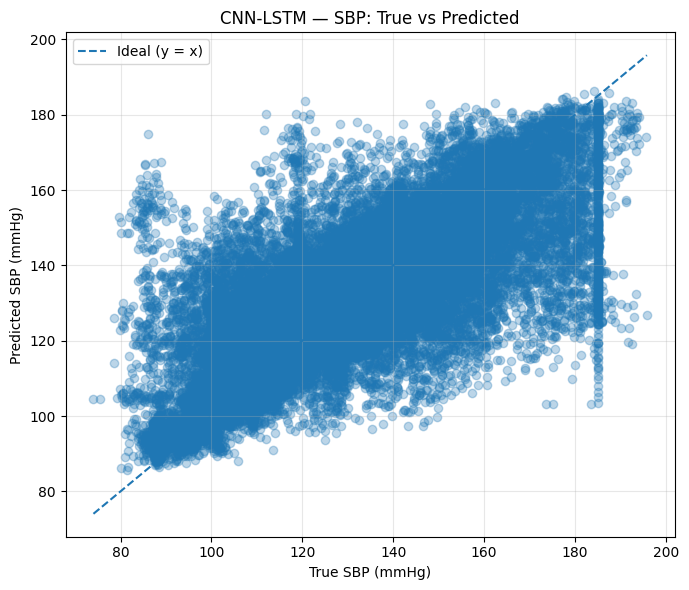

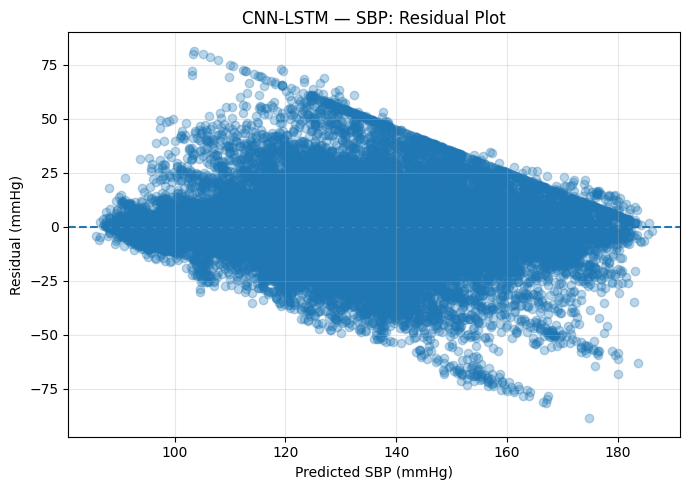

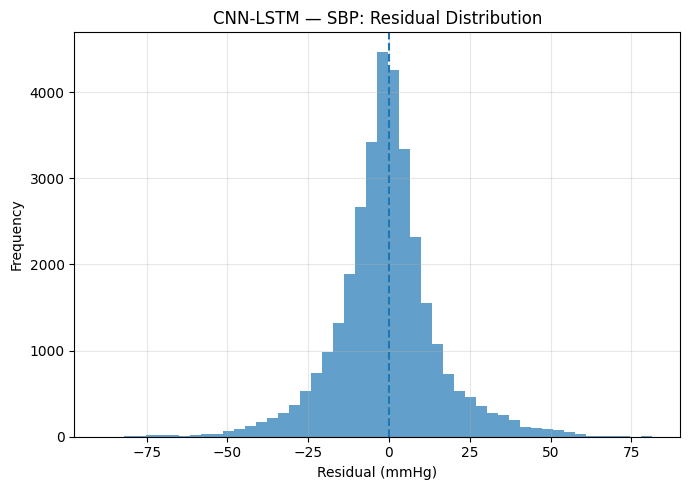

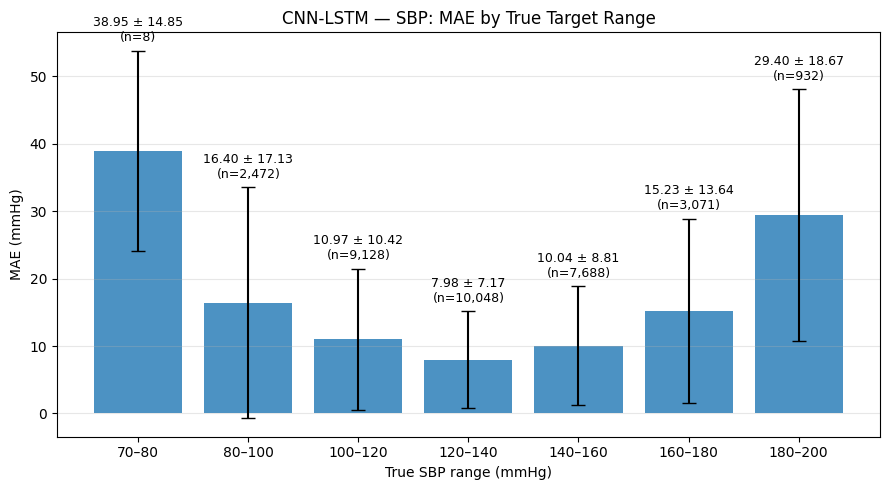

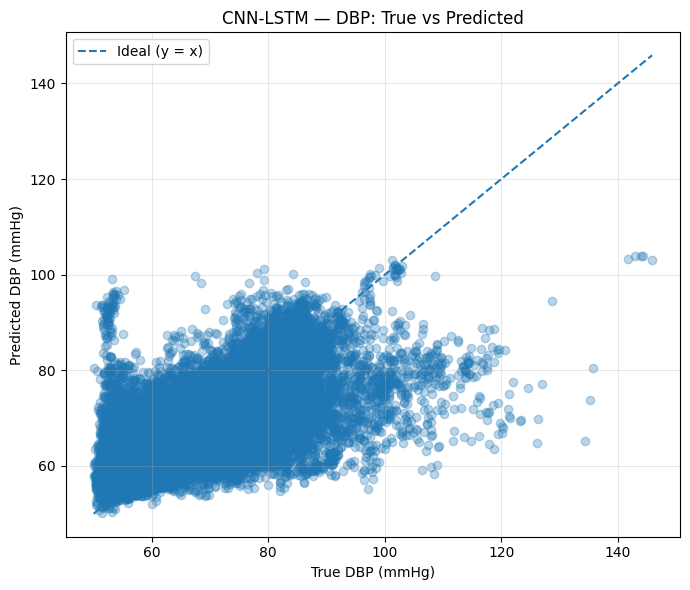

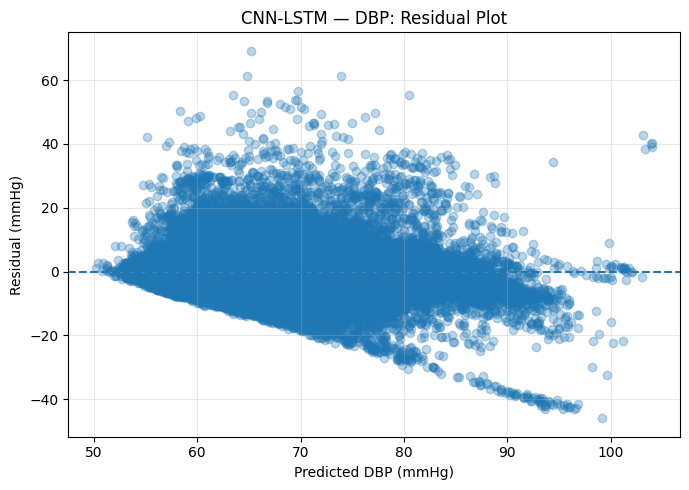

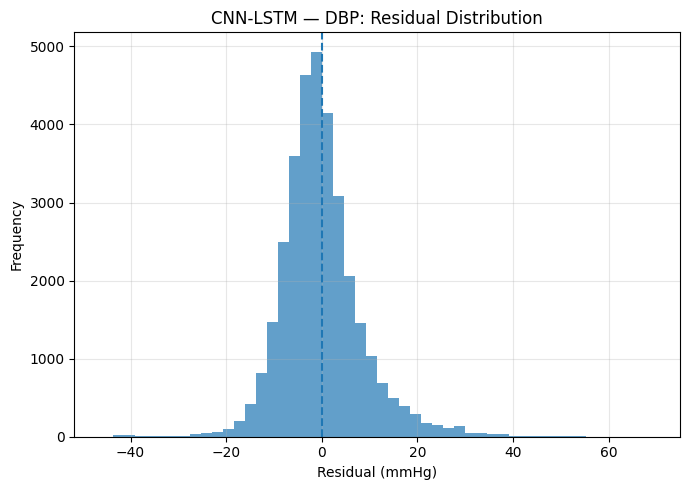

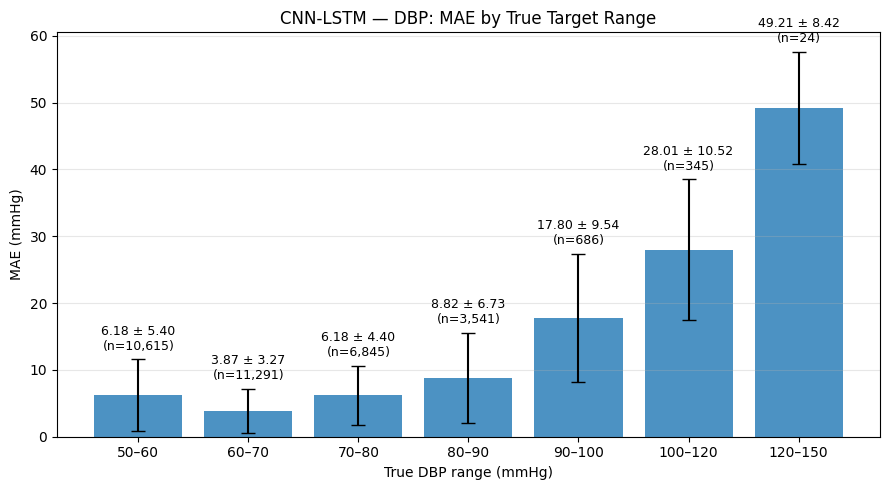

In [5]:
model_cnn_lstm, results_cnn_lstm = train_cnn_lstm_baseline(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

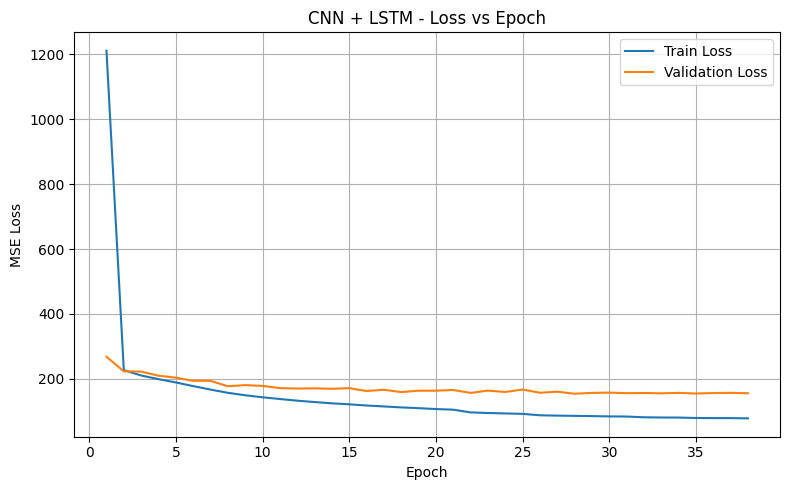

In [6]:
plot_loss_vs_epoch(
    results_cnn_lstm["history"],
    model_name="CNN + LSTM"
)

Number of VitalDB cases: 1968


CNN-LSTM VitalDB prediction: 100%|██████████| 1968/1968 [02:32<00:00, 12.88case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 24.0718
MSE : 579.4539
R²  : -0.3602
MAE : 19.1502

DBP
RMSE: 13.4058
MSE : 179.7152
R²  : -0.1103
MAE : 10.5626


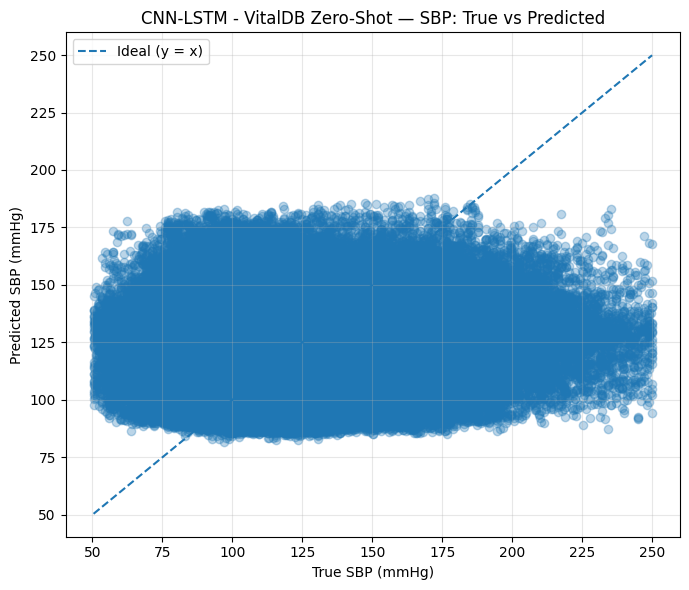

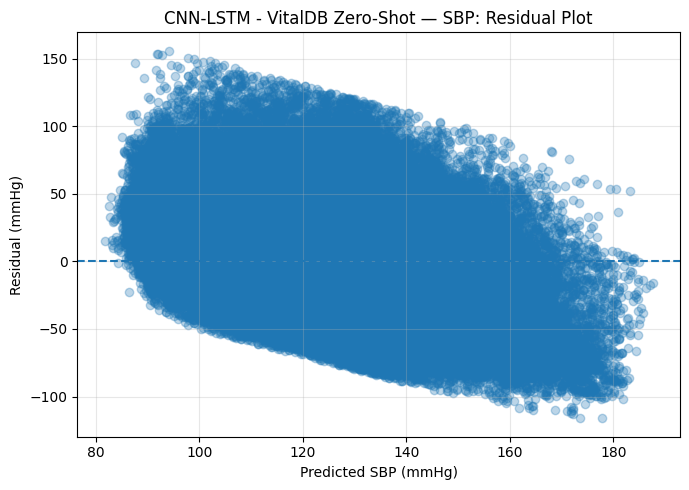

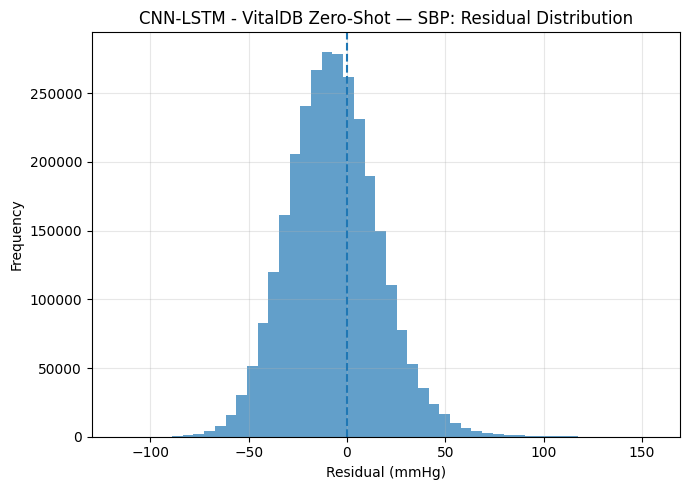

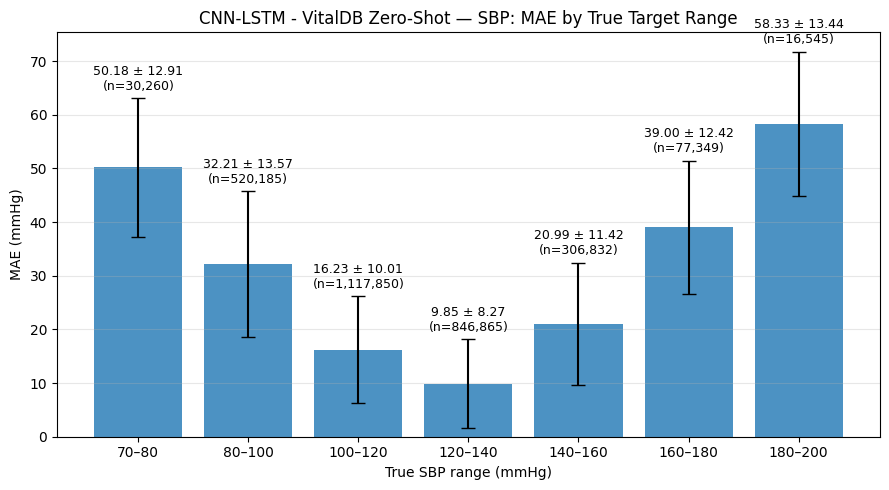

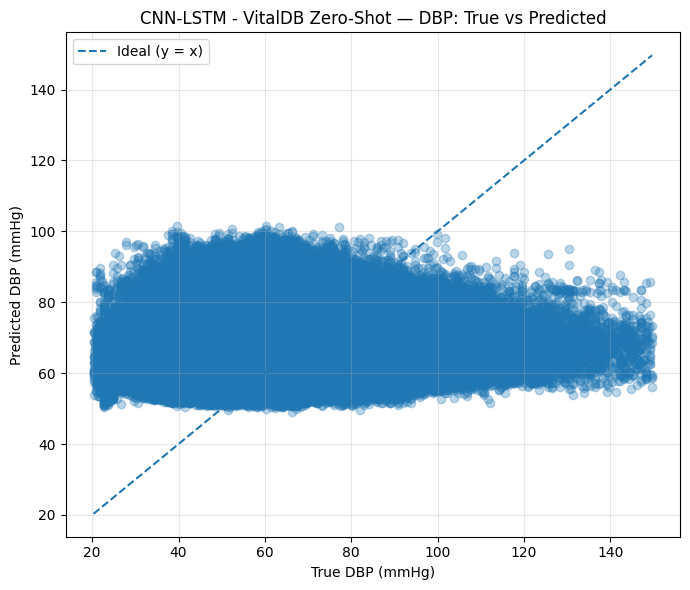

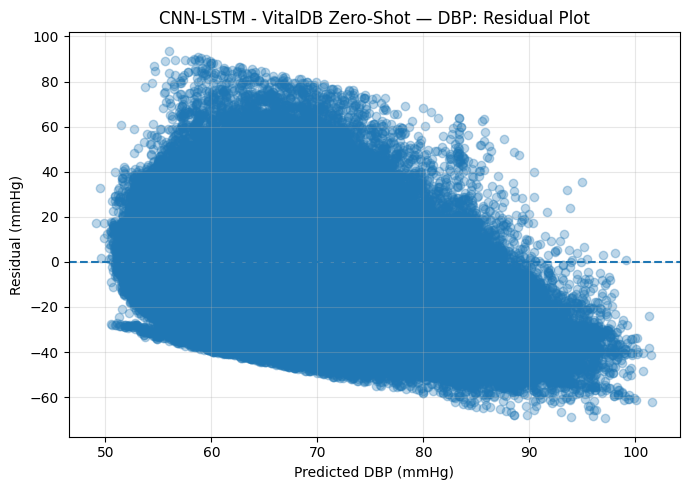

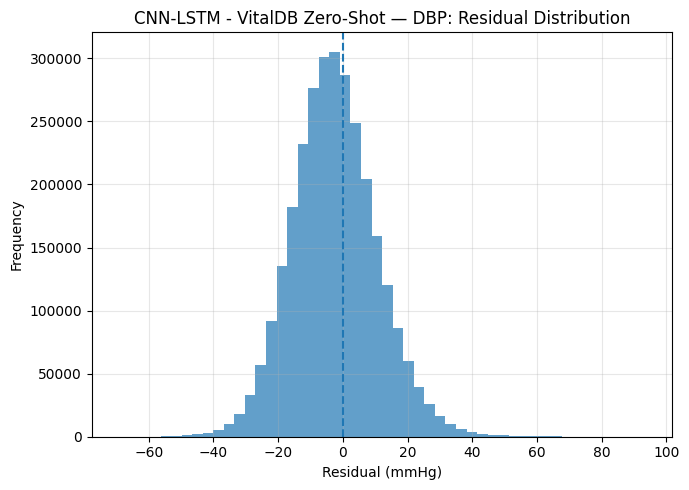

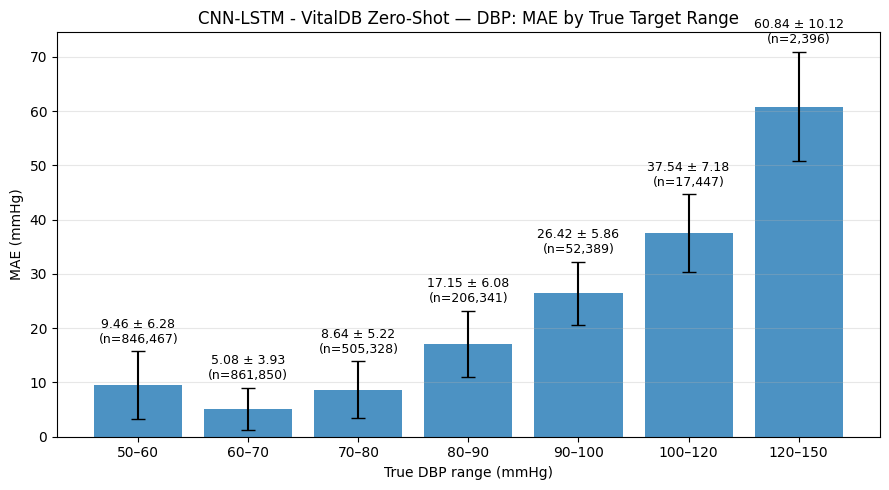

In [7]:
results_cnn_lstm_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_cnn_lstm, base_dir=BASE_DIR, batch_size=256 )

####

Device: cuda
X_train: torch.Size([263103, 1, 1000])
y_train: torch.Size([263103, 2])
X_val: torch.Size([33223, 1, 1000])
y_val: torch.Size([33223, 2])
X_test: torch.Size([33347, 1, 1000])
y_test: torch.Size([33347, 2])
Epoch 01/50 | Train Loss: 1048.1611 | Val Loss: 285.7598 | Train SBP RMSE: 41.132 | Train DBP RMSE: 20.111 | Val SBP RMSE: 21.102 | Val DBP RMSE: 11.236 | LR: 1.00e-03
Epoch 02/50 | Train Loss: 233.1999 | Val Loss: 222.5708 | Train SBP RMSE: 18.987 | Train DBP RMSE: 10.291 | Val SBP RMSE: 18.568 | Val DBP RMSE: 10.018 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 204.6473 | Val Loss: 225.8684 | Train SBP RMSE: 17.656 | Train DBP RMSE: 9.876 | Val SBP RMSE: 18.738 | Val DBP RMSE: 10.031 | LR: 1.00e-03
Epoch 04/50 | Train Loss: 187.1693 | Val Loss: 195.5730 | Train SBP RMSE: 16.763 | Train DBP RMSE: 9.662 | Val SBP RMSE: 17.260 | Val DBP RMSE: 9.657 | LR: 1.00e-03
Epoch 05/50 | Train Loss: 172.6873 | Val Loss: 191.6225 | Train SBP RMSE: 16.051 | Train DBP RMSE: 9.368 | Val SBP 

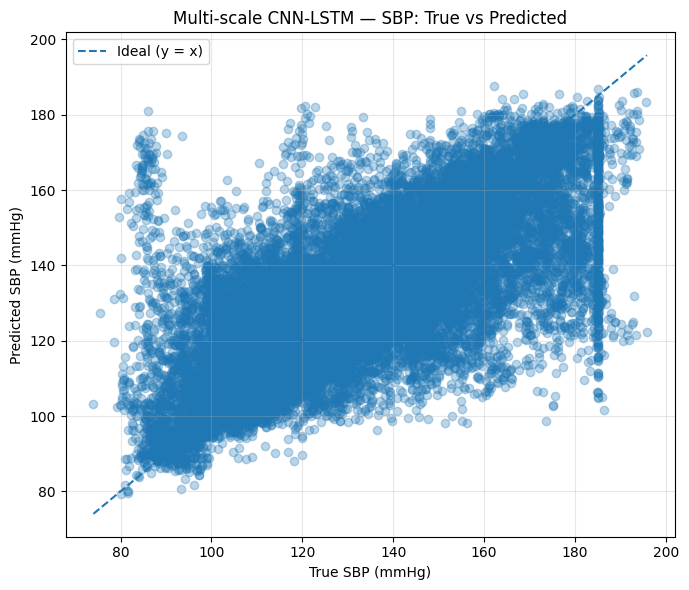

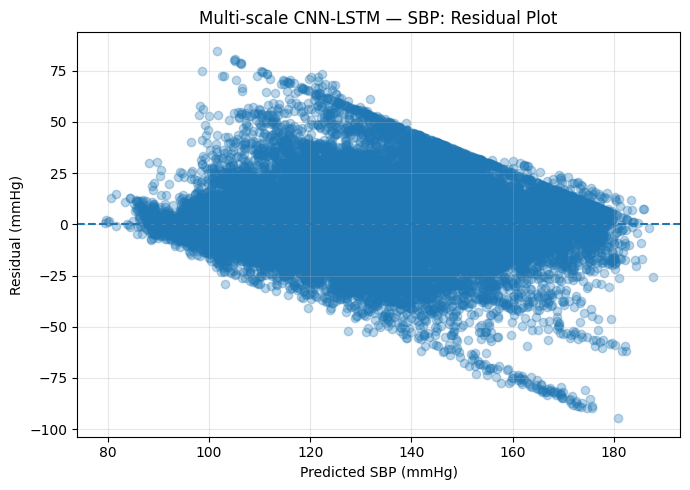

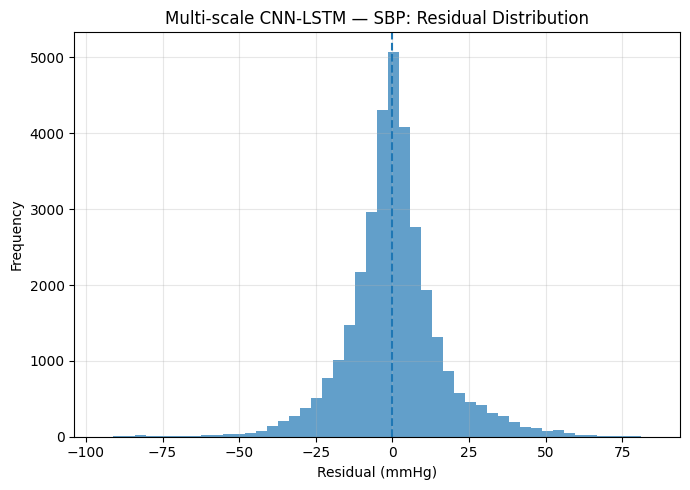

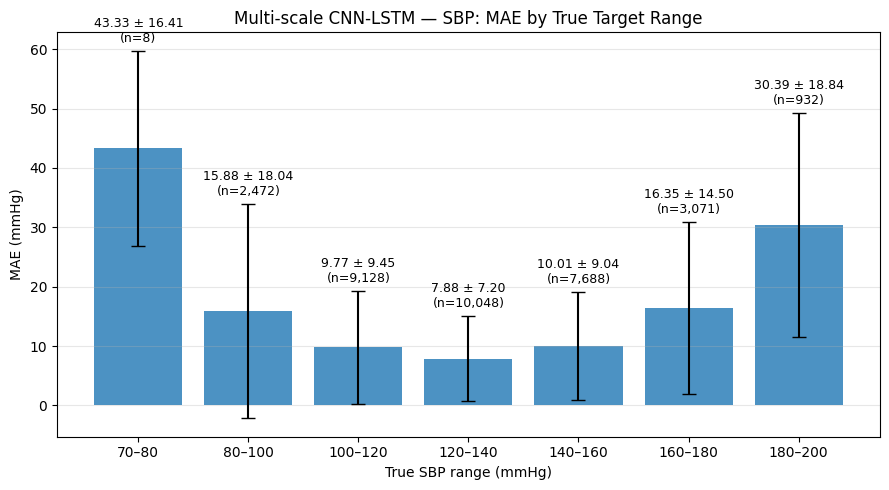

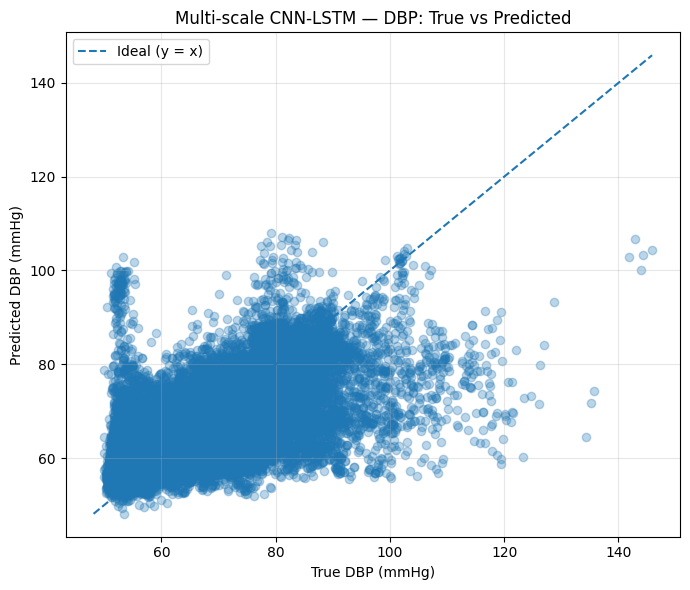

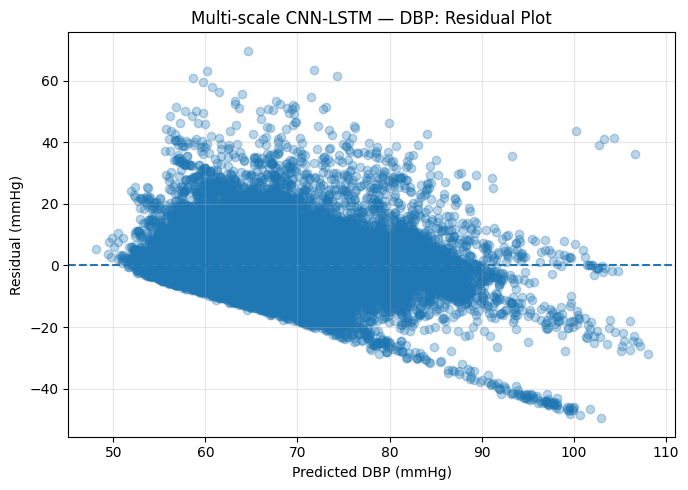

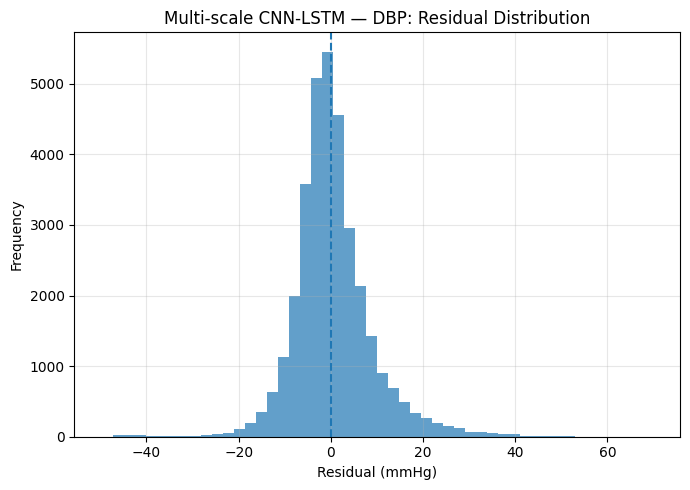

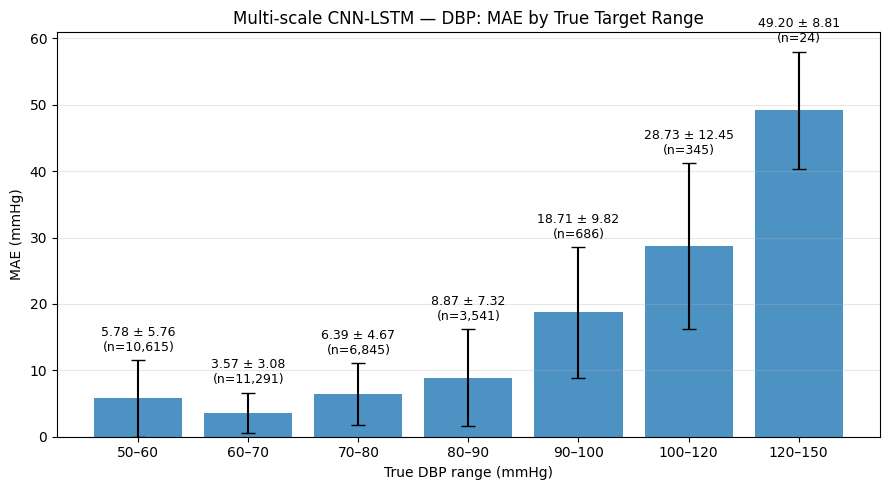

In [8]:
model_multiscale, results_multiscale = train_multiscale_cnn_lstm( 
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    X_test=X_test,
     y_test=y_test, 
     batch_size=256, 
     epochs=50, 
     lr=1e-3, 
     patience=10 )


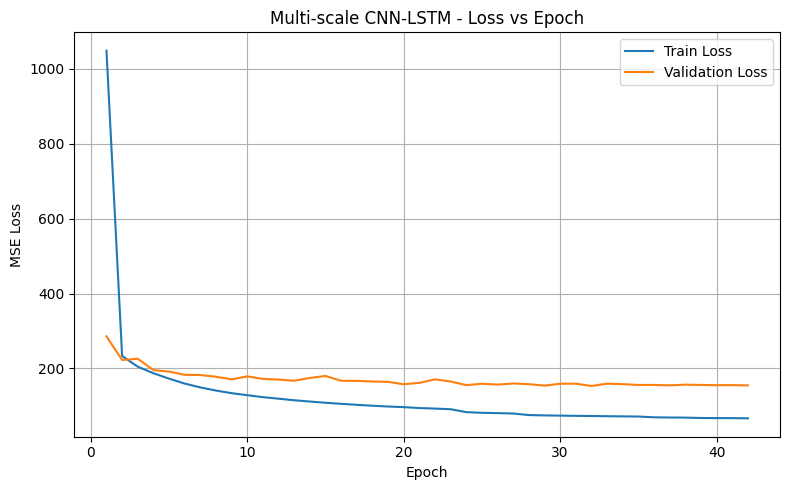

In [9]:
plot_loss_vs_epoch( results_multiscale["history"], model_name="Multi-scale CNN-LSTM" )

Number of VitalDB cases: 1968


CNN-LSTM VitalDB prediction: 100%|██████████| 1968/1968 [03:35<00:00,  9.12case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 27.3659
MSE : 748.8907
R²  : -0.7580
MAE : 22.0592

DBP
RMSE: 16.6422
MSE : 276.9627
R²  : -0.7111
MAE : 13.2645


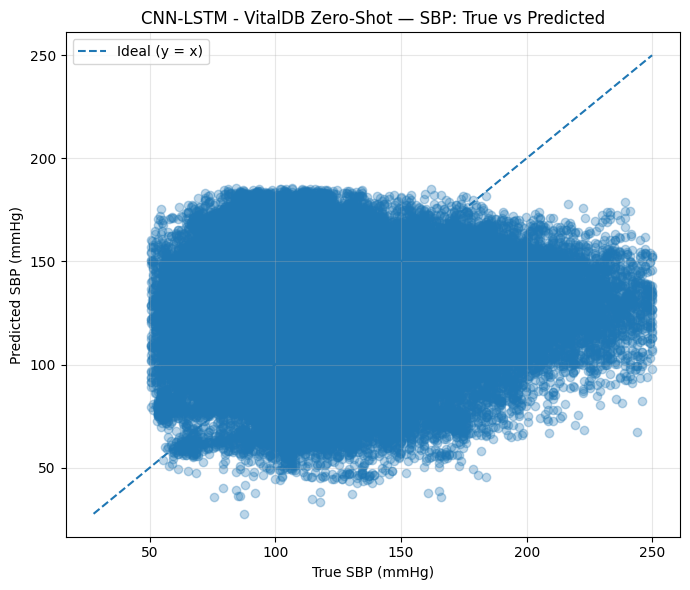

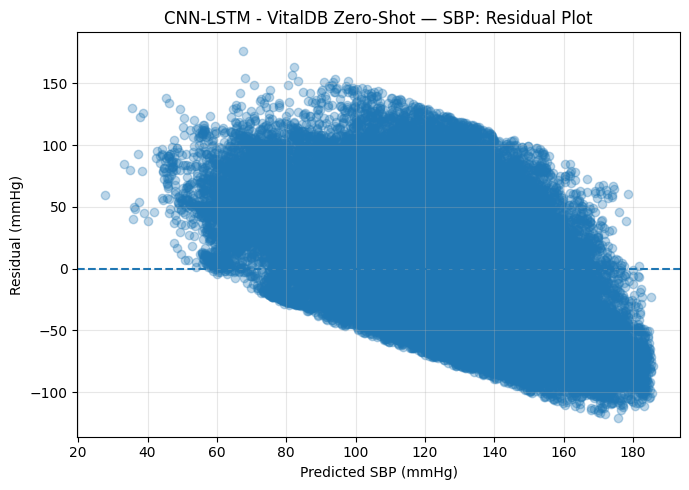

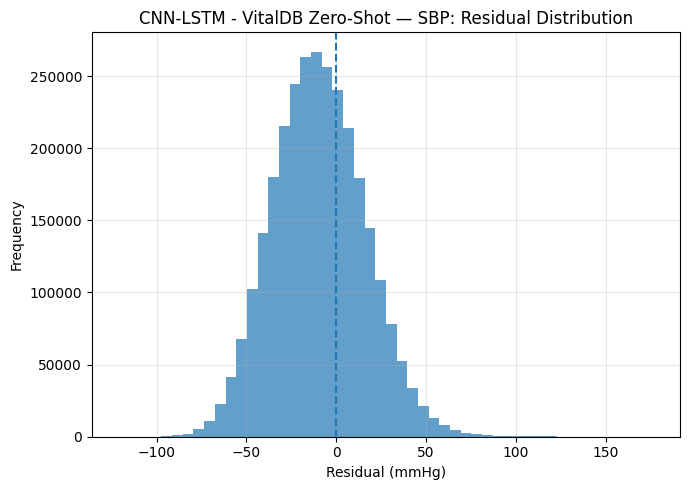

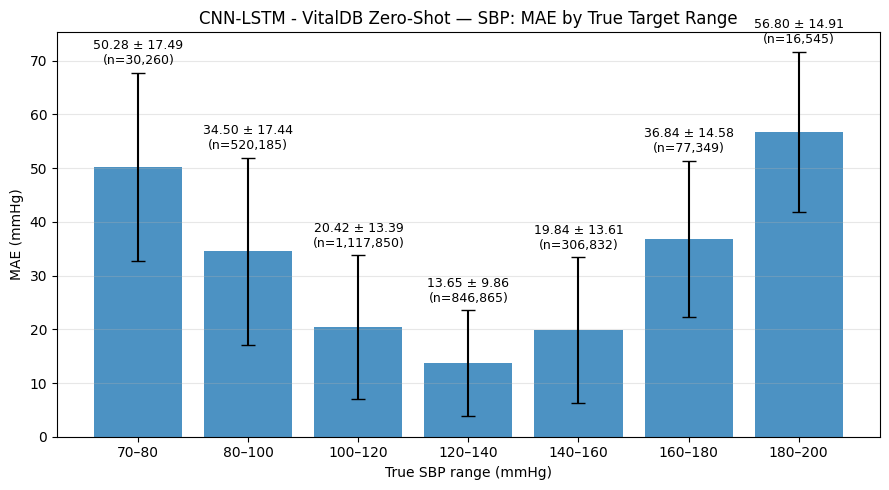

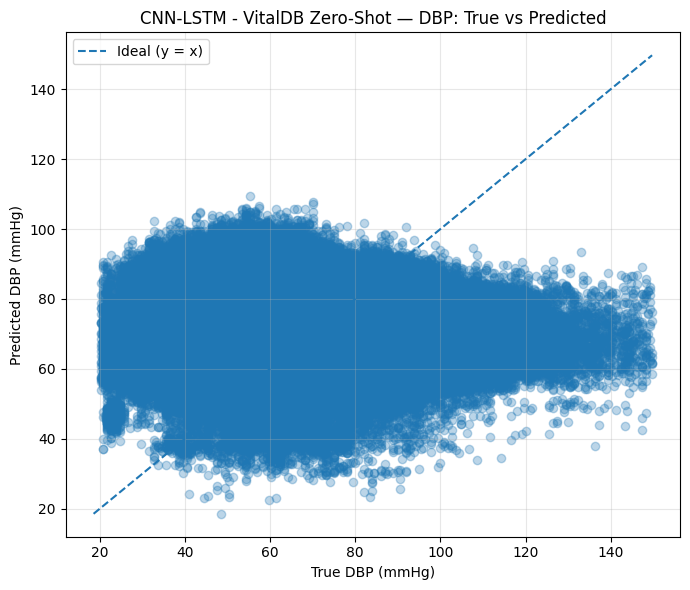

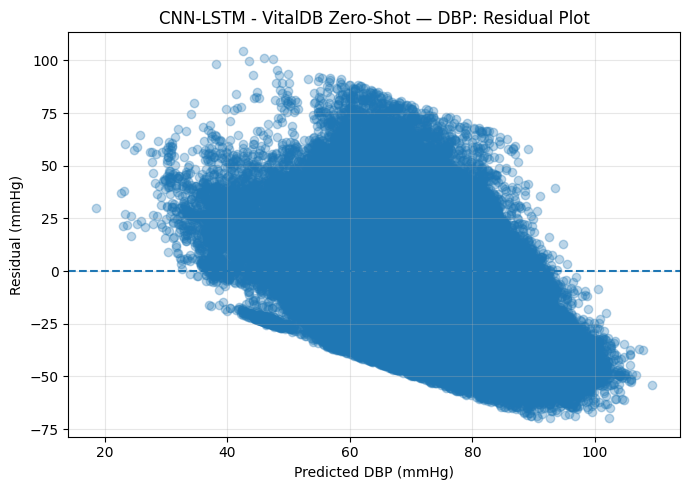

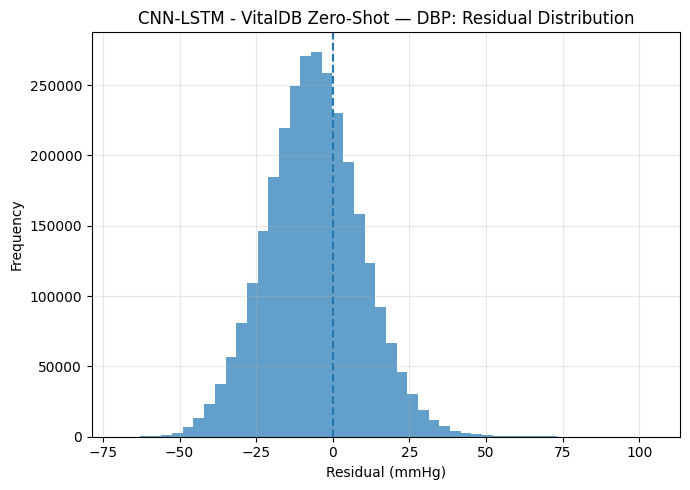

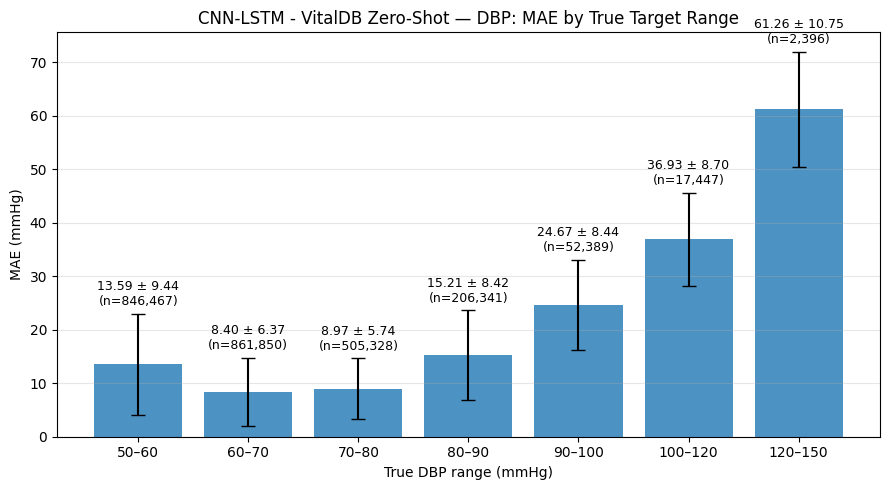

In [10]:
results_multiscale_vitaldb = evaluate_cnn_lstm_vitaldb( model=model_multiscale, base_dir=BASE_DIR, batch_size=256 )

####

In [11]:
model_attention, results_attention = train_cnn_lstm_attention(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    batch_size=256,
    epochs=50,
    lr=1e-3,
    patience=10
)

Epoch 01/50 | Train Loss: 1153.2414 | Val Loss: 386.6610 | Train RMSE SBP/DBP: 42.90/21.59 | Val RMSE SBP/DBP: 24.26/13.60
Epoch 02/50 | Train Loss: 332.8347 | Val Loss: 355.9882 | Train RMSE SBP/DBP: 22.75/12.16 | Val RMSE SBP/DBP: 23.37/12.88
Epoch 03/50 | Train Loss: 258.6464 | Val Loss: 500.7926 | Train RMSE SBP/DBP: 19.96/10.91 | Val RMSE SBP/DBP: 27.07/16.39
Epoch 04/50 | Train Loss: 222.5647 | Val Loss: 383.5340 | Train RMSE SBP/DBP: 18.32/10.46 | Val RMSE SBP/DBP: 23.28/15.00
Epoch 05/50 | Train Loss: 200.0233 | Val Loss: 550.3688 | Train RMSE SBP/DBP: 17.26/10.10 | Val RMSE SBP/DBP: 28.35/17.23
Epoch 06/50 | Train Loss: 185.8623 | Val Loss: 736.7434 | Train RMSE SBP/DBP: 16.61/9.79 | Val RMSE SBP/DBP: 33.23/19.21
Epoch 07/50 | Train Loss: 168.9510 | Val Loss: 643.2022 | Train RMSE SBP/DBP: 15.74/9.50 | Val RMSE SBP/DBP: 31.05/17.94
Epoch 08/50 | Train Loss: 162.2456 | Val Loss: 565.1536 | Train RMSE SBP/DBP: 15.41/9.33 | Val RMSE SBP/DBP: 28.90/17.17
Epoch 09/50 | Train Loss: 

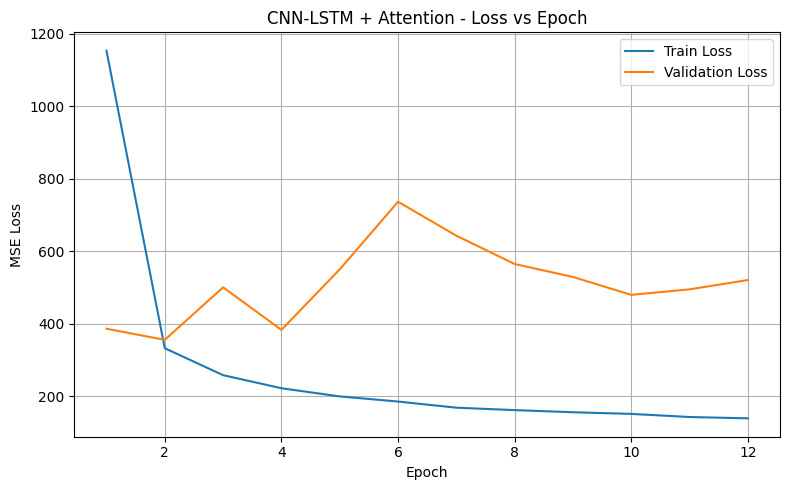

In [12]:
plot_loss_vs_epoch(
    results_attention["history"],
    model_name="CNN-LSTM + Attention"
)

Number of VitalDB cases: 1968


CNN-LSTM VitalDB prediction: 100%|██████████| 1968/1968 [02:49<00:00, 11.58case/s]



CNN-LSTM
VITALDB ZERO-SHOT RESULTS

SBP
RMSE: 23.6575
MSE : 559.6779
R²  : -0.3138
MAE : 18.5569

DBP
RMSE: 13.8083
MSE : 190.6692
R²  : -0.1780
MAE : 10.7977


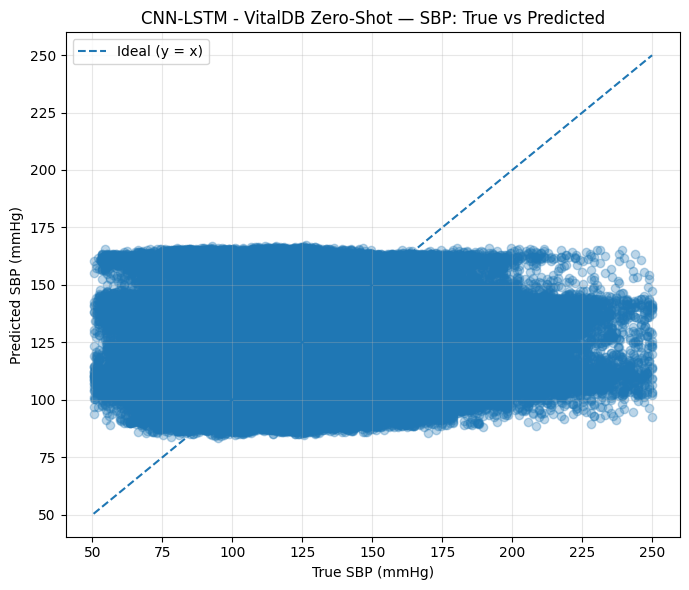

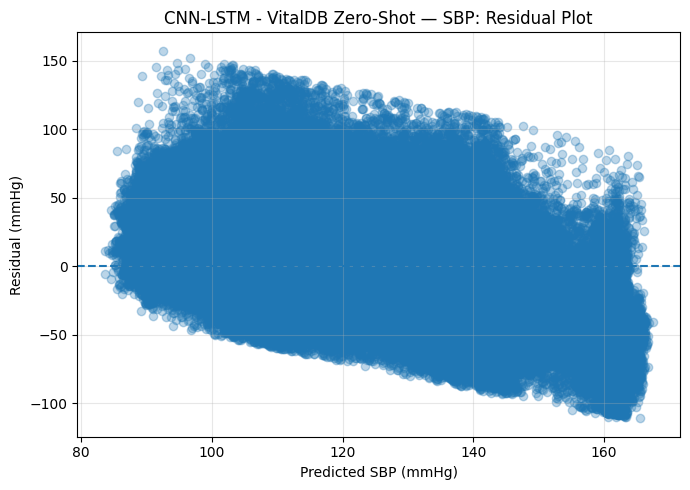

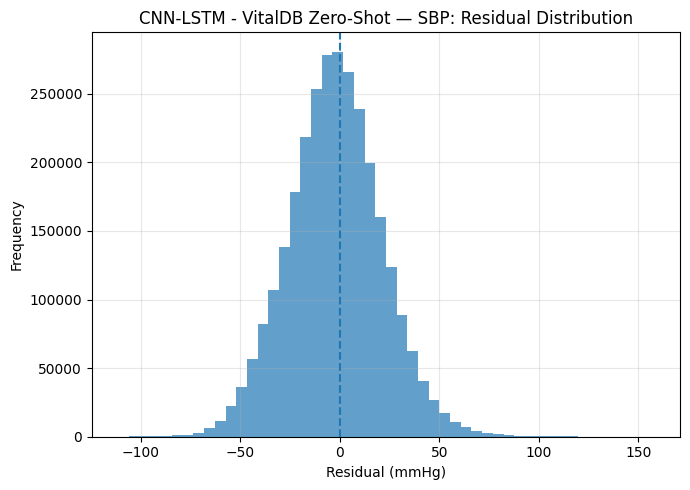

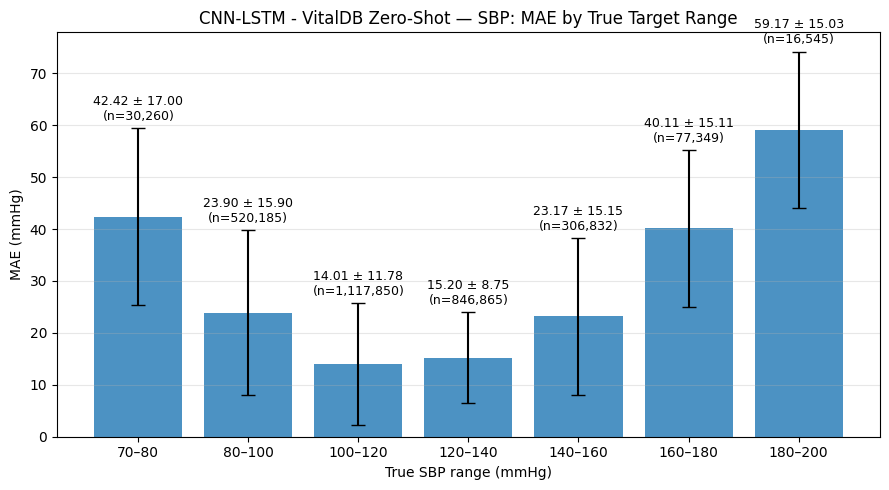

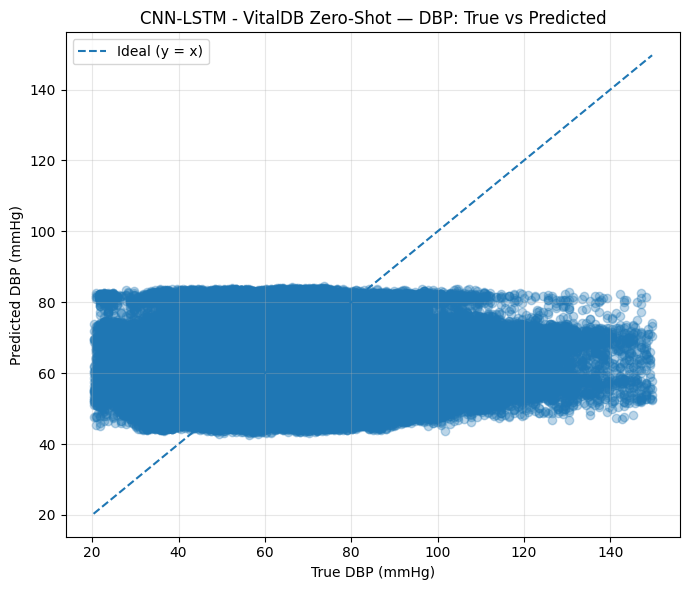

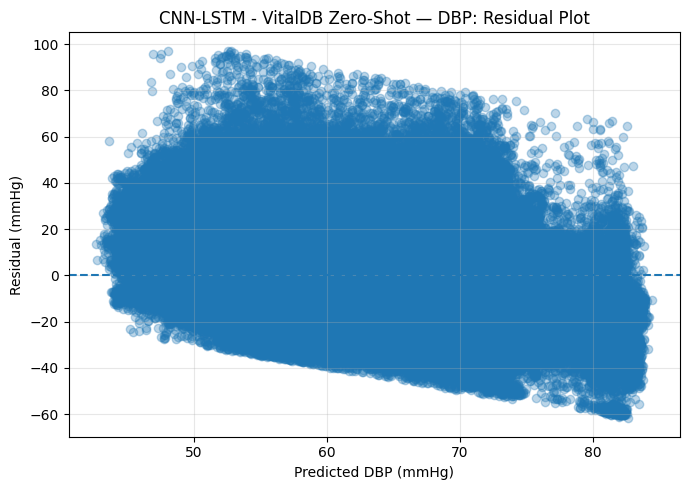

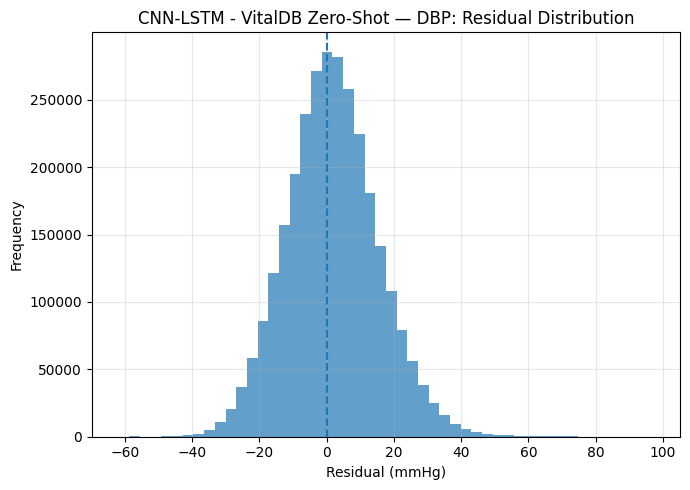

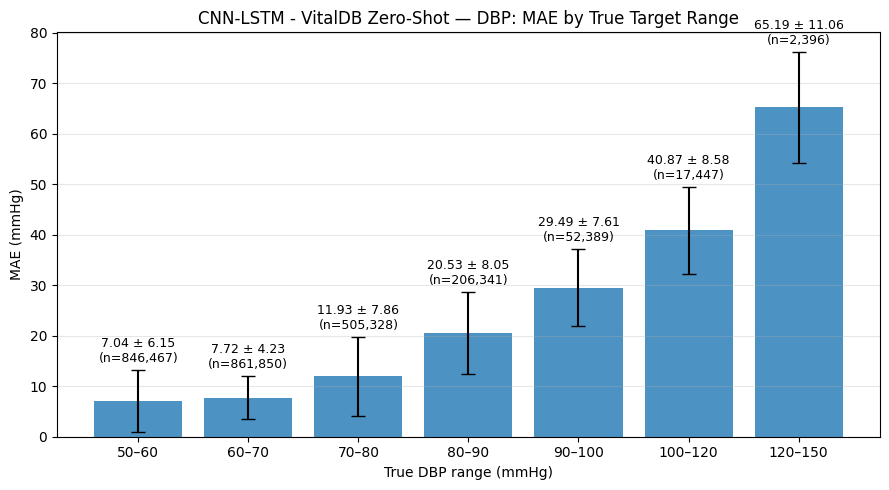

In [13]:

results_attention_vitaldb = evaluate_cnn_lstm_vitaldb(
    model=model_attention,
    base_dir=BASE_DIR,
    batch_size=256
)